# 9.2. Converting Raw Text into Sequence Data

- #### **1.** Load text as strings into memory.
- #### **2.** Split the strings into tokens (e.g., words or characters).
- #### **3.** Build a vocabulary dictionary to associate each vocabulary element with a numerical index.
- #### **4.** Convert the text into sequences of numerical indices

In [1]:
import collections
import random
import re
import torch
from d2l import torch as d2l

## 9.2.1. Reading the Dataset

In [2]:
class TimeMachine(d2l.DataModule): #@save
    """The Time Machine dataset."""
    def _download(self):
        fname = d2l.download(d2l.DATA_URL + 'timemachine.txt', self.root,
                             '090b5e7e70c295757f55df93cb0a180b9691891a')
        with open(fname) as f:
            return f.read()

data = TimeMachine()
raw_text = data._download()
raw_text[:60]

'The Time Machine, by H. G. Wells [1898]\n\n\n\n\nI\n\n\nThe Time Tra'

In [3]:
@d2l.add_to_class(TimeMachine)  #@save
def _preprocess(self, text):
    return re.sub('[^A-Za-z]+', ' ', text).lower()

text = data._preprocess(raw_text)
text[:60]

'the time machine by h g wells i the time traveller for so it'

## 9.2.2. Tokenization

In [4]:
@d2l.add_to_class(TimeMachine)  #@save
def _tokenize(self, text):
    return list(text)

tokens = data._tokenize(text)
','.join(tokens[:30])

't,h,e, ,t,i,m,e, ,m,a,c,h,i,n,e, ,b,y, ,h, ,g, ,w,e,l,l,s, '

In [5]:
print(tokens[:40])

['t', 'h', 'e', ' ', 't', 'i', 'm', 'e', ' ', 'm', 'a', 'c', 'h', 'i', 'n', 'e', ' ', 'b', 'y', ' ', 'h', ' ', 'g', ' ', 'w', 'e', 'l', 'l', 's', ' ', 'i', ' ', 't', 'h', 'e', ' ', 't', 'i', 'm', 'e']


## 9.2.3. Vocabulary

In [6]:
class Vocab:  #@save
    """Vocabulary for text."""
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        # Flatten a 2D list if needed
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                  reverse=True)
        # The list of unique tokens
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [
            token for token, freq in self.token_freqs if freq >= min_freq])))
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]

    @property
    def unk(self):  # Index for the unknown token
        return self.token_to_idx['<unk>']

In [7]:
vocab = Vocab(tokens)
indices = vocab[tokens[:10]]
print('indices:', indices)
print('words:', vocab.to_tokens(indices))

indices: [21, 9, 6, 0, 21, 10, 14, 6, 0, 14]
words: ['t', 'h', 'e', ' ', 't', 'i', 'm', 'e', ' ', 'm']


In [8]:
len(vocab)

28

## 9.2.4. Putting It All Together

In [9]:
@d2l.add_to_class(TimeMachine)  #@save
def build(self, raw_text, vocab=None):
    tokens = self._tokenize(self._preprocess(raw_text))
    if vocab is None: vocab = Vocab(tokens)
    corpus = [vocab[token] for token in tokens]
    return corpus, vocab

corpus, vocab = data.build(raw_text)
len(corpus), len(vocab)

(173428, 28)

## 9.2.5. Exploratory Language Statistics

In [10]:
text[:60]

'the time machine by h g wells i the time traveller for so it'

In [11]:
words = text.split()
vocab = Vocab(words)
vocab.token_freqs[:10]

[('the', 2261),
 ('i', 1267),
 ('and', 1245),
 ('of', 1155),
 ('a', 816),
 ('to', 695),
 ('was', 552),
 ('in', 541),
 ('that', 443),
 ('my', 440)]

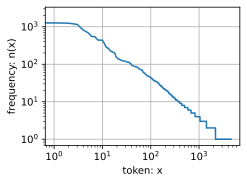

In [12]:
freqs = [freq for token, freq in vocab.token_freqs]
d2l.plot(freqs, xlabel='token: x', ylabel='frequency: n(x)',
         xscale='log', yscale='log')

In [13]:
print(freqs[:60])
print(len(freqs))

[2261, 1267, 1245, 1155, 816, 695, 552, 541, 443, 440, 437, 354, 281, 270, 243, 221, 216, 204, 200, 158, 152, 137, 137, 134, 129, 127, 123, 122, 122, 122, 120, 118, 114, 114, 113, 113, 112, 106, 105, 103, 94, 93, 92, 92, 91, 89, 88, 87, 86, 85, 85, 85, 84, 84, 82, 79, 77, 75, 74, 74]
4579


In [14]:
bigram_tokens = ['--'.join(pair) for pair in zip(words[:-1], words[1:])]
bigram_vocab = Vocab(bigram_tokens)
bigram_vocab.token_freqs[:10]

[('of--the', 309),
 ('in--the', 169),
 ('i--had', 130),
 ('i--was', 112),
 ('and--the', 109),
 ('the--time', 102),
 ('it--was', 99),
 ('to--the', 85),
 ('as--i', 78),
 ('of--a', 73)]

In [15]:
bigram_vocab.token_freqs[:20]

[('of--the', 309),
 ('in--the', 169),
 ('i--had', 130),
 ('i--was', 112),
 ('and--the', 109),
 ('the--time', 102),
 ('it--was', 99),
 ('to--the', 85),
 ('as--i', 78),
 ('of--a', 73),
 ('i--saw', 68),
 ('i--could', 67),
 ('and--i', 62),
 ('in--a', 61),
 ('that--i', 61),
 ('time--traveller', 60),
 ('for--the', 51),
 ('to--me', 51),
 ('into--the', 49),
 ('at--the', 49)]

In [16]:
trigram_tokens = ['--'.join(triple) for triple in zip(
    words[:-2], words[1:-1], words[2:])]
trigram_vocab = Vocab(trigram_tokens)
trigram_vocab.token_freqs[:10]

[('the--time--traveller', 59),
 ('the--time--machine', 30),
 ('the--medical--man', 24),
 ('it--seemed--to', 16),
 ('it--was--a', 15),
 ('here--and--there', 15),
 ('seemed--to--me', 14),
 ('i--did--not', 14),
 ('i--saw--the', 13),
 ('i--began--to', 13)]

In [17]:
trigram_vocab.token_freqs[:20]

[('the--time--traveller', 59),
 ('the--time--machine', 30),
 ('the--medical--man', 24),
 ('it--seemed--to', 16),
 ('it--was--a', 15),
 ('here--and--there', 15),
 ('seemed--to--me', 14),
 ('i--did--not', 14),
 ('i--saw--the', 13),
 ('i--began--to', 13),
 ('for--a--moment', 12),
 ('said--the--time', 12),
 ('out--of--the', 12),
 ('i--could--see', 12),
 ('a--kind--of', 11),
 ('said--the--medical', 11),
 ('one--of--the', 11),
 ('i--saw--a', 11),
 ('and--i--was', 11),
 ('i--could--not', 11)]

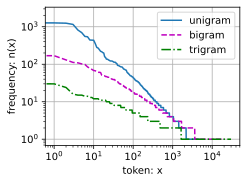

In [18]:
bigram_freqs = [freq for token, freq in bigram_vocab.token_freqs]
trigram_freqs = [freq for token, freq in trigram_vocab.token_freqs]
d2l.plot([freqs, bigram_freqs, trigram_freqs], xlabel='token: x',
         ylabel='frequency: n(x)', xscale='log', yscale='log',
         legend=['unigram', 'bigram', 'trigram'])

## 9.2.7. Exercises

### Ex.1

In [53]:
tab = []
for i in range(0, 20):
    vocab_test = Vocab(words, i)
    tab.append(vocab_test.__len__())
print(tab)

[4580, 4580, 2183, 1420, 1044, 825, 680, 586, 502, 439, 400, 362, 330, 313, 288, 274, 262, 244, 235, 230]


### Ex.2

#### Unigrams

In [53]:
class FreqData(d2l.SyntheticRegressionData):
    def __init__(self, X, y, num_train=1000, batch_size=32):
        self.save_hyperparameters()

In [92]:
unig_tab = [freq for _, freq in vocab.token_freqs]
unig_x = torch.log(torch.tensor([freq for id_x, freq in enumerate(unig_tab)][::-1])).reshape(-1,1)
unig_y = torch.log(torch.arange(len(unig_x), 0, -1)).reshape(-1,1)
data_unig = FreqData(unig_x, unig_y)

In [93]:
unig_y.shape, unig_x.shape

(torch.Size([4579, 1]), torch.Size([4579, 1]))

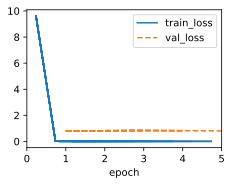

In [94]:
model = d2l.LinearRegression(0.1)
trainer = d2l.Trainer(max_epochs=5)
trainer.fit(model, data_unig)

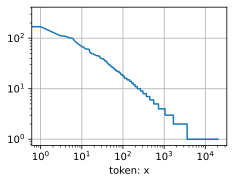

In [95]:
d2l.plot(bigram_freqs, xlabel='token: x', yscale='log', xscale='log')

In [98]:
model.net.weight.item()

-0.4312640428543091

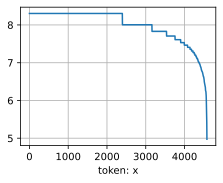

In [97]:
d2l.plot([model(x).detach().item() for x in unig_x], xlabel='token: x')

In [83]:
[model(x).detach().item() for x in unig_x]

[0.9630866050720215,
 1.4983649253845215,
 1.514554500579834,
 1.5839052200317383,
 1.9050240516662598,
 2.0533671379089355,
 2.2662787437438965,
 2.2848825454711914,
 2.4695916175842285,
 2.4758715629577637,
 2.4821949005126953,
 2.6768736839294434,
 2.89031982421875,
 2.927227020263672,
 3.0246057510375977,
 3.1123147010803223,
 3.1334657669067383,
 3.186293601989746,
 3.2045960426330566,
 3.4224605560302734,
 3.4582419395446777,
 3.554269790649414,
 3.554269790649414,
 3.5747337341308594,
 3.6098804473876953,
 3.624321460723877,
 3.653900146484375,
 3.661445140838623,
 3.661445140838623,
 3.661445140838623,
 3.6767220497131348,
 3.6922554969787598,
 3.7241291999816895,
 3.7241291999816895,
 3.732272148132324,
 3.732272148132324,
 3.740488052368164,
 3.7913761138916016,
 3.8001370429992676,
 3.8179116249084473,
 3.902418613433838,
 3.9123034477233887,
 3.922295570373535,
 3.922295570373535,
 3.932396411895752,
 3.9529361724853516,
 3.963379383087158,
 3.973942756652832,
 3.9846277236